# Convolutional Neural Network

## Why CNN?
Traditional neural networks flatten images into a single 1D vector right away, destroying spatial relationships. CNNs are deisgned to process pixel while preserving their spatial relationships. This is done through using shared weights (filters) across entire image, reducing the number of parameters needed. 

## The Convolution Operation
At each step of an convolution operation, it multiplies the pixel values by the filter's weight and adds them to create a single number.

## Filters
Small filters (eg. 3 x 3) act as feature detectors. Early Layers might filters that detect simple edges, while deeper layers detect complex shapes like ears or wheels.

## Feature Maps
Feature array is the output array generated by sliding a filter over the image. It represents where specific features were found in the original image.

## Pooling
Pooling downsamples the feature maps, reducing their size and computational cost while keeping the most important information. The most common type is Max Pooling, which takes the maximum value from a small sliding window (e.g., 2×2), making the network robust to small shifts or distortions in the image.

## Flattening
Once the image has passed through convolutional and pooling layers, the resulting 3D feature maps are unrolled into a 1D column vector. This prepares the data for the final classification stage.

## Fully Connected (Dense) Layers
It takes the flattened, high-level features learned by the convolutions and uses them to output a final prediction.

## Use cases
Generally used for image classification, object detection, facial recognition etc. 


# CNN Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")

Using device: cuda
PyTorch Version: 2.6.0+cu124
True


In [ ]:
# Normalize images in range [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

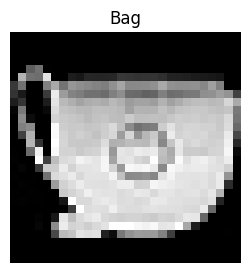

In [ ]:
# Create DataLoaders to handle batching (batch size of 64)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display the first image
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(3,3))
# PyTorch tensors are (Color, Height, Width), squeeze out the color channel for grayscale plotting
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(class_names[labels[0].item()])
plt.axis('off')
plt.show()

## Testing Image Convolution

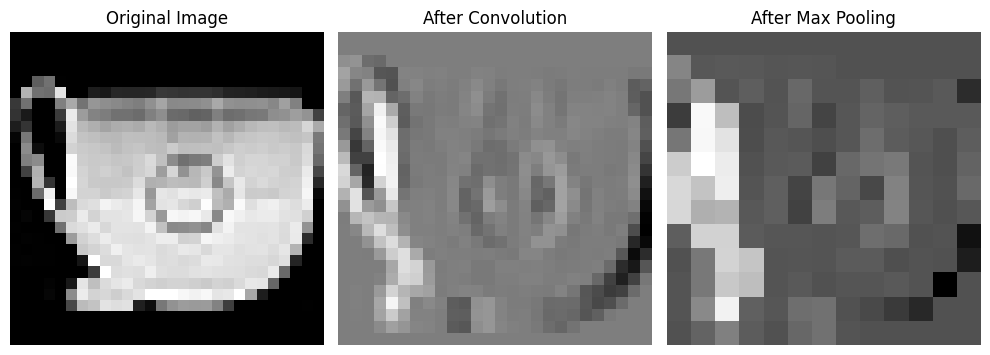

In [ ]:
# Add a batch dimension: (1, 1, 28, 28) for pytorch tensor
sample_image = images[0].unsqueeze(0) 

# 3x3 filter to detect vertical edges
# PyTorch weights shape: (Out_Channels, In_Channels, Kernel_Height, Kernel_Width)
vertical_filter = torch.tensor([[[[-1., 0., 1.],
                                  [-1., 0., 1.],
                                  [-1., 0., 1.]]]])

# Apply Convolution using PyTorch's functional API
convolved_image = F.conv2d(sample_image, vertical_filter, padding=0)

# Apply Max Pooling (2x2 window)
pooled_image = F.max_pool2d(convolved_image, kernel_size=2, stride=2)

# Helper function to format tensors for matplotlib, removes batch/channel dims and converts to numpy
def format_for_plot(tensor):
    return tensor.squeeze().detach().numpy()

# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(format_for_plot(sample_image), cmap='gray'); axes[0].set_title('Original Image')
axes[1].imshow(format_for_plot(convolved_image), cmap='gray'); axes[1].set_title('After Convolution')
axes[2].imshow(format_for_plot(pooled_image), cmap='gray'); axes[2].set_title('After Max Pooling')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Defining CNN Architecture

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # First Convolutional Layer: 1 input channel (grayscale), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        
        # Second Convolutional Layer: 32 input channels, 64 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Max Pooling Layer: 2x2 window
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully Connected (Dense) Layers
        # After two 2x2 poolings, the 28x28 image becomes 7x7. 
        # Flattened size = 64 channels * 7 height * 7 width
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 output classes

    def forward(self, x):
        # Pass through Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        
        # Pass through Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the tensor for the fully connected layers
        x = x.view(-1, 64 * 7 * 7) 
        
        # Pass through Fully Connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Training the model

In [ ]:
# Define the loss function (criterion) and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []
train_accuracies = []

print("Starting training...")
for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass: compute predictions
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass: compute gradients
        loss.backward()
        
        # Optimize: update weights
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Starting training...
Epoch [1/5], Loss: 0.4152, Accuracy: 85.10%
Epoch [2/5], Loss: 0.2704, Accuracy: 90.17%
Epoch [3/5], Loss: 0.2263, Accuracy: 91.73%
Epoch [4/5], Loss: 0.1932, Accuracy: 92.92%
Epoch [5/5], Loss: 0.1686, Accuracy: 93.64%


## Model Evaluation


Final Test Accuracy: 91.75%


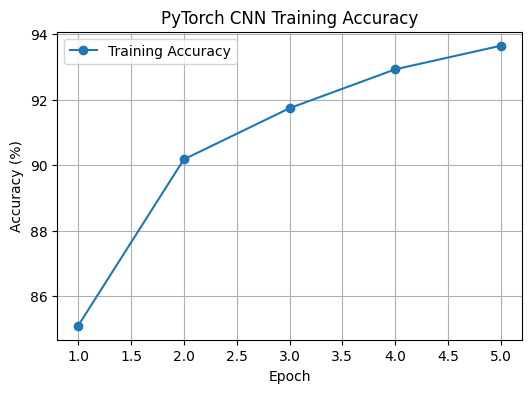

In [13]:
# Set the model to evaluation mode
model.eval()
test_correct = 0
test_total = 0

# Turn off gradient tracking for evaluation to save memory and speed up computation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f'\nFinal Test Accuracy: {test_acc:.2f}%')

# Plot training accuracy over time
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs+1), train_accuracies, marker='o', label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('PyTorch CNN Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Model saving and testing

In [ ]:
# Save the model's weights (state_dict)
MODEL_PATH = './fashion_mnist_cnn.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model weights saved to {MODEL_PATH}")

loaded_model = SimpleCNN().to(device)

# Load the saved weights into the new model
loaded_model.load_state_dict(torch.load(MODEL_PATH))

# Set model to evluation mode to turns off things like dropout or batch normalization training behaviors
loaded_model.eval()
print("Model loaded and set to evaluation mode.")

Model weights saved to ./fashion_mnist_cnn.pth
Model loaded and set to evaluation mode.


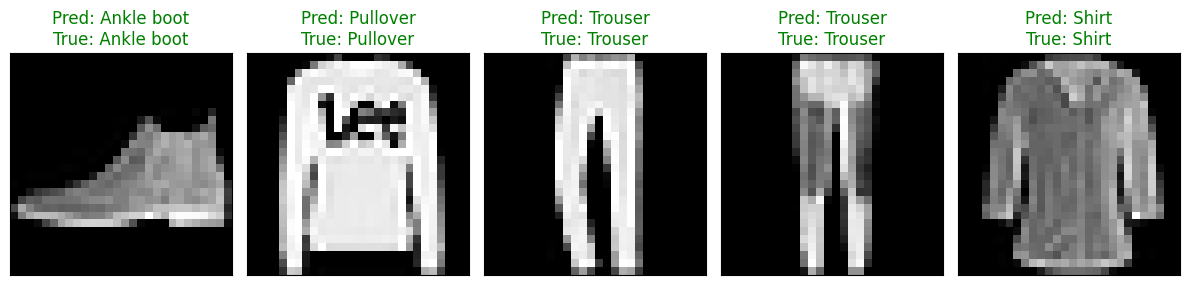

In [15]:
# Grab a single batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move the data to the correct device (GPU or CPU)
images, labels = images.to(device), labels.to(device)

# Turn off gradient calculations for inference
with torch.no_grad():
    # Pass the images through our loaded model
    outputs = loaded_model(images)
    
    # Get the predicted class (the one with the highest score)
    _, predicted = torch.max(outputs, 1)

# Visualize the first 5 predictions
fig = plt.figure(figsize=(12, 4))
for idx in range(5):
    # Add a subplot for each image
    ax = fig.add_subplot(1, 5, idx+1, xticks=[], yticks=[])
    
    # PyTorch tensors are on the GPU/CPU, we need to move them to CPU and convert to NumPy for Matplotlib
    img = images[idx].cpu().squeeze().numpy()
    ax.imshow(img, cmap='gray')
    
    # Get the string names of the true and predicted labels
    true_label = class_names[labels[idx].item()]
    pred_label = class_names[predicted[idx].item()]
    
    # Color the title green if correct, red if wrong
    title_color = "green" if pred_label == true_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=title_color)

plt.tight_layout()
plt.show()